In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import scarf

scarf.configure_output(level="ERROR", progress=False)
datasets = scarf.cytebase.connect("scarf_docs")
outputs = TemporaryDirectory()
output_dir = Path(outputs.name)

In [2]:
tenx_h5 = datasets.download_dataset(
    name="tenx_10K_pbmc-v1_atacseq",
    destination=output_dir,
)
mtx_dir = datasets.download_dataset(
    name="xin_1K_pancreas_rnaseq",
    destination=output_dir,
)
h5ad_dir = datasets.download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination=output_dir,
)

tenx_h5, mtx_dir, h5ad_dir

Downloading bucket files: 79995014 / 79995014 complete

Downloading bytes: 79995014 / 79995014 complete

Downloading bucket files: 54544298 / 54544298 complete

Downloading bytes: 54544298 / 54544298 complete

Downloading bucket files: 52477898 / 52477898 complete

Downloading bytes: 52477898 / 52477898 complete

(PosixPath('/tmp/tmpexkmabko/tenx_10K_pbmc-v1_atacseq'),
 PosixPath('/tmp/tmpexkmabko/xin_1K_pancreas_rnaseq'),
 PosixPath('/tmp/tmpexkmabko/bastidas-ponce_4K_pancreas-d15_rnaseq'))

In [3]:
atac_store = output_dir / "pbmc_atac.zarr"
reader = scarf.CrH5Reader(str(tenx_h5 / "data.h5"))
scarf.CrToZarr(
    reader,
    zarr_loc=str(atac_store),
    mem_budget="8G",
).dump()

In [4]:
ds_atac = scarf.DataStore(str(atac_store))
ds_atac

DataStore has 8728 (8728) cells with 1 assays: ATAC
   Cell metadata:
            'I', 'ids', 'names', 'ATAC_nCounts', 'ATAC_nFeatures', 
          
   ATAC assay has 89796 features and following metadata:
            'I', 'ids', 'names', 'genome', 'dropOuts', 
            'nCells', 'derivation', 'feature_type'

In [5]:
candidates = scarf.inspect_mtx(str(mtx_dir))
candidates

(MtxCandidate(source='/tmp/tmpexkmabko/xin_1K_pancreas_rnaseq', matrixPath='/tmp/tmpexkmabko/xin_1K_pancreas_rnaseq/matrix.mtx.gz', featurePath='/tmp/tmpexkmabko/xin_1K_pancreas_rnaseq/features.tsv.gz', cellPath='/tmp/tmpexkmabko/xin_1K_pancreas_rnaseq/barcodes.tsv.gz', matrixOrientation='featuresByCells', nCells=1600, nFeatures=39846, nEntries=9160987, archivePath=None, cellMetadataPath=None, featureReferencePath=None, cellIdKeys=(), relatedFiles=()),)

In [6]:
mtx_store = output_dir / "xin_1K.zarr"
reader = scarf.MtxReader(candidates[0], dtype="uint64")
scarf.MtxToZarr(
    reader,
    zarr_loc=str(mtx_store),
    dtype="uint64",
).dump()

In [7]:
ds_mtx = scarf.DataStore(str(mtx_store))
ds_mtx.RNA.rawData.dtype, ds_mtx.RNA.rawData.shape

(dtype('<u8'), (1600, 39846))

In [8]:
h5ad_path = str(h5ad_dir / "data.h5ad")
inspection = scarf.inspect_h5ad(h5ad_path)
inspection

H5adInspectResult(h5adFn='/tmp/tmpexkmabko/bastidas-ponce_4K_pancreas-d15_rnaseq/data.h5ad', matrixKey='X', matrixCandidates=('X', 'layers/spliced', 'layers/unspliced'), matrixEncoding='csr', integerLike=True, cellAttrsKey='obs', cellIdsKey='index', featureAttrsKey='var', featureIdsKey='index', featureNameKey='index', categoryNamesKey='__categories', assaySplitKey=None, suggestedAssays={}, layers=('spliced', 'unspliced'), title=None, description=None, nCells=3696, nFeatures=27998)

In [9]:
reader = scarf.H5adReader.from_inspect(
    inspection,
    embedding_roles={"X_umap": "umap"},
    cluster_keys=("clusters",),
)

pancreas_store = output_dir / "differentiating_pancreatic_cells.zarr"
h5ad_import = scarf.H5adToZarr(
    reader,
    zarr_loc=str(pancreas_store),
    analysis_assay="RNA",
).dump()
h5ad_import.embeddingArtifacts, h5ad_import.clusterArtifacts

(mappingproxy({'X_umap': ArtifactRef(assay='RNA', kind='embedding', artifact_id='1439fb138714...')}),
 mappingproxy({'clusters': ArtifactRef(assay='RNA', kind='cluster_labels', artifact_id='ac926838fdee...')}))

In [10]:
ds = scarf.DataStore(str(pancreas_store))

imported_umap = np.asarray(
    ds.load_artifact(h5ad_import.embeddingArtifacts["X_umap"])["values"][:]
)
imported_clusters = np.asarray(
    ds.load_artifact(h5ad_import.clusterArtifacts["clusters"])["values"][:]
)
imported_umap.shape, imported_clusters.shape

((3696, 2), (3696,))

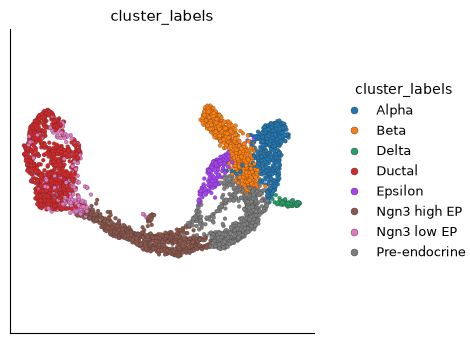

In [11]:
ds.plots.embedding(
    layout=h5ad_import.embeddingArtifacts["X_umap"],
    color_by=h5ad_import.clusterArtifacts["clusters"],
)

In [12]:
scarf.writers.to_mtx(
    assay=ds.RNA,
    mtx_directory=str(output_dir / "diff_pancreas"),
)

In [13]:
adata = ds.to_anndata(from_assay="RNA")
adata.obsm["X_umap"] = imported_umap
adata.obs["clusters"] = imported_clusters
h5ad_export = output_dir / "diff_pancreas.h5ad"
adata.write_h5ad(h5ad_export)

In [14]:
import anndata as ad

adata = ad.read_h5ad(h5ad_export)
sorted(adata.obsm.keys()), adata.obsm["X_umap"].shape

(['X_umap'], (3696, 2))

In [15]:
all_names = ds.RNA.feats.fetch_all("names").astype(str)
name_lookup = {name.upper(): name for name in all_names}
panel = [name_lookup[gene] for gene in ("GCG", "SST", "KRT19")]
selected = ds.to_anndata(
    from_assay="RNA",
    matrix="raw",
    feature_names=panel,
)
{
    "shape": selected.shape,
    "genes": selected.var_names.tolist(),
}

{'shape': (3696, 3), 'genes': ['Gcg', 'Sst', 'Krt19']}

In [16]:
csv_path = output_dir / "toy_counts.csv"
csv_path.write_text(
    "quality,geneA,geneB,geneC\n"
    "10,1,0,2\n"
    "20,0,3,0\n"
    "30,4,5,6\n"
    "40,7,0,8\n"
    "50,9,10,0\n",
    encoding="utf-8",
)

csv_zarr = output_dir / "toy_csv.zarr"
reader = scarf.CSVReader(
    str(csv_path),
    cell_data_cols=["quality"],
)
scarf.CSVtoZarr(
    reader,
    zarr_loc=str(csv_zarr),
    assay_name="RNA",
    dtype=np.dtype("uint16"),
).dump()
ds_csv = scarf.DataStore(str(csv_zarr))
ds_csv.cells.head()

,I,ids,names,RNA_nFeatures,RNA_nCounts,quality
0,True,cell_0,cell_0,2.0,3.0,10
1,True,cell_1,cell_1,1.0,3.0,20
2,True,cell_2,cell_2,3.0,15.0,30
3,True,cell_3,cell_3,2.0,15.0,40
4,True,cell_4,cell_4,2.0,19.0,50


In [17]:
from scipy.sparse import csr_matrix

mat = csr_matrix(
    (
        [1, 10, 15, 10, 20, 2, 3, 1, 5],
        ([0, 0, 0, 1, 1, 1, 2, 2, 2], [1, 3, 8, 2, 3, 1, 2, 8, 9]),
    ),
    shape=(3, 10),
)
sparse_zarr = output_dir / "toy_sparse.zarr"
scarf.SparseToZarr(
    mat,
    zarr_loc=str(sparse_zarr),
    cell_ids=[f"cell_{i}" for i in range(mat.shape[0])],
    feature_ids=[f"feat_{i}" for i in range(mat.shape[1])],
    assay_name="RNA",
).dump()
ds_sparse = scarf.DataStore(str(sparse_zarr))
ds_sparse

DataStore has 3 (3) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nCounts', 'RNA_nFeatures', 
          
   RNA assay has 10 features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          